# Validating Q-Alchemy preparation circuits with the hosted sparse simulator

This notebook closes the loop between the two halves of the SDK:

1. **Q-Alchemy initializer** — turn a target state vector into a quantum *preparation circuit* (`q_alchemy_as_qasm`).
2. **Hosted sparse simulator** — run that circuit on the hosted Q-Alchemy `SparseSimulator` and read back the resulting state.

We then **compare** the simulator's state against (a) the original target and (b) Qiskit's local dense reference. Because the prepared state is sparse, the sparse simulator reproduces it exactly.

> Requires the `examples` extra (`pip install "q-alchemy-sdk-py[examples]"`) and a `Q_ALCHEMY_API_KEY` (here loaded from `../.env`).

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity

from q_alchemy import q_alchemy_as_qasm, SparseSimulator

load_dotenv("../.env")
assert os.getenv("Q_ALCHEMY_API_KEY"), "Set Q_ALCHEMY_API_KEY (e.g. in ../.env)"

## 1. A target state

We build a **sparse** 5-qubit state: only a handful of computational-basis amplitudes are non-zero. This is exactly the regime where a sparse simulator shines — the prepared state never fills the full $2^n$ vector.

In [2]:
rng = np.random.default_rng(7)
num_qubits = 5
dim = 2 ** num_qubits
num_nonzero = 5

target = np.zeros(dim, dtype=complex)
support = rng.choice(dim, size=num_nonzero, replace=False)
target[support] = rng.normal(size=num_nonzero) + 1j * rng.normal(size=num_nonzero)
target /= np.linalg.norm(target)

print(f"{num_qubits} qubits, {np.count_nonzero(target)} non-zero amplitudes")
for i in sorted(support):
    print(f"  |{i:0{num_qubits}b}>  {target[i]: .4f}")

5 qubits, 5 non-zero amplitudes
  |10010>  -0.4596+0.2270j
  |10100>   0.0279+0.1654j
  |11010>   0.6211+0.0489j
  |11011>  -0.2876-0.0136j
  |11111>  -0.2281-0.4312j


## 2. Prepare a circuit with the Q-Alchemy initializer

`q_alchemy_as_qasm` returns an OpenQASM 2 preparation circuit for the target state. With `max_fidelity_loss=0.0` it aims for an exact preparation.

/home/carsten/q-alchemy/q-alchemy-sdk-py/.venv/lib/python3.12/site-packages/pinexq/client/job_management/enterjma.py:90: UserWarning: Version mismatch between 'pinexq_client' (v9.7.0) and 'JobManagementAPI' (v9.3.0)! 
  warnings.warn(


preparation circuit: 5 qubits, 29 gates, depth 11


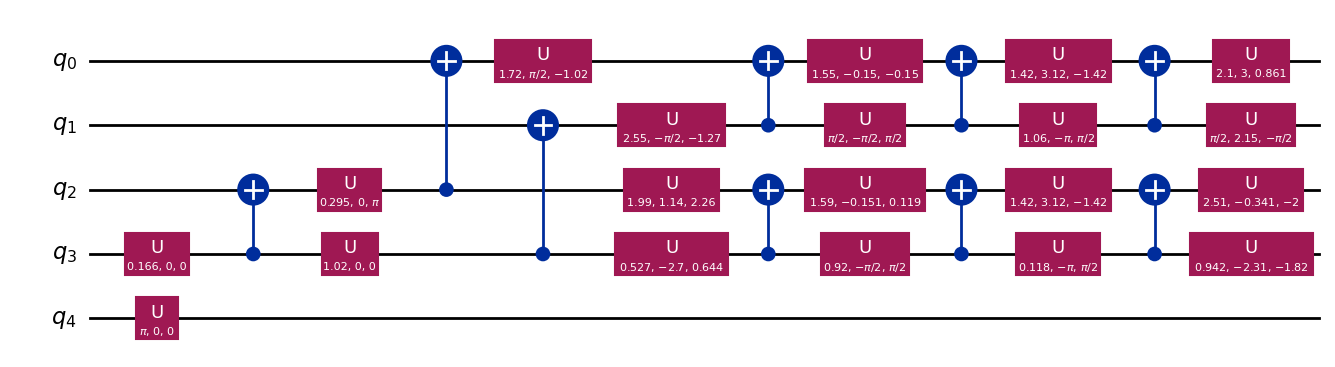

In [3]:
qasm = q_alchemy_as_qasm(target, max_fidelity_loss=0.0, basis_gates=["u", "cx"])
prep = QuantumCircuit.from_qasm_str(qasm)
print(f"preparation circuit: {prep.num_qubits} qubits, {prep.size()} gates, depth {prep.depth()}")
prep.draw(output="mpl", fold=-1)

## 3. Run the circuit on the hosted sparse simulator

`SparseSimulator.sparse_statevector` submits the circuit to the hosted simulator and returns only the non-zero amplitudes. The circuit input form is chosen automatically (here: inline OpenQASM).

In [4]:
sim = SparseSimulator(job_completion_timeout_sec=180)

sv = sim.sparse_statevector(prep, sparse_index_format="bitstring")
print(f"simulator returned {sv.nnz} non-zero amplitudes ({sv.index_convention}):")
for index, amplitude in sv.amplitudes_dict().items():
    print(f"  |{index}>  {amplitude: .4f}")

simulator returned 5 non-zero amplitudes (little_endian):
  |10010>  -0.1093-0.5008j
  |10100>  -0.1672-0.0129j
  |11010>  -0.1974+0.5910j
  |11011>   0.0826-0.2758j
  |11111>   0.4736-0.1172j


## 4. Compare against the target (and Qiskit)

`SparseStatevectorResult.to_dense()` materializes the simulator state in Qiskit's ordering, so we can score it directly. We expect:

- **simulator vs target** ≈ 1 — the initializer prepared the right state and the simulator reproduced it,
- **simulator vs Qiskit** ≈ 1 — the hosted simulator agrees with Qiskit's local dense reference.

In [5]:
simulator_state = Statevector(sv.to_dense())
qiskit_state = Statevector(prep)
target_state = Statevector(target)

print(f"fidelity  simulator vs target : {state_fidelity(simulator_state, target_state):.8f}")
print(f"fidelity  simulator vs qiskit : {state_fidelity(simulator_state, qiskit_state):.8f}")
print(f"fidelity  qiskit    vs target : {state_fidelity(qiskit_state, target_state):.8f}")

fidelity  simulator vs target : 1.00000000
fidelity  simulator vs qiskit : 1.00000000
fidelity  qiskit    vs target : 1.00000000


## 5. Measurement counts vs Born-rule probabilities

Sampling the circuit on the simulator should reproduce the ideal $|\langle x | \psi \rangle|^2$ distribution.

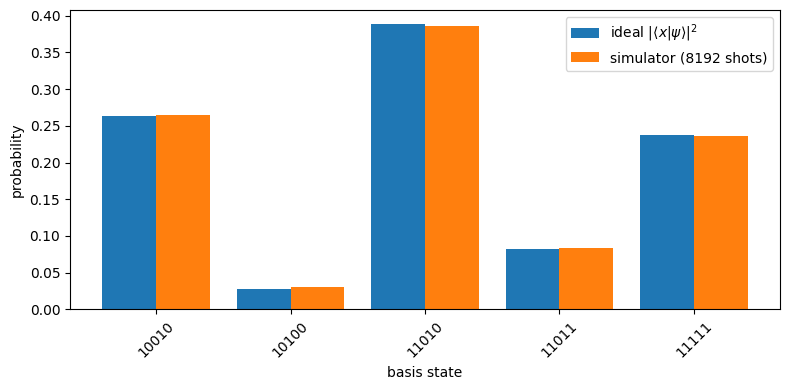

In [6]:
measured = prep.copy()
measured.measure_all()

shots = 8192
counts = sim.counts(measured, shots=shots, seed_simulator=42).counts

# Empirical frequencies vs ideal probabilities, over the state's support.
probs = np.abs(target) ** 2
labels = [f"{i:0{num_qubits}b}" for i in sorted(support)]
ideal = [probs[i] for i in sorted(support)]
empirical = [counts.get(label, 0) / shots for label in labels]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, ideal, width=0.4, label="ideal $|\\langle x|\\psi\\rangle|^2$")
ax.bar(x + 0.2, empirical, width=0.4, label=f"simulator ({shots} shots)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel("basis state")
ax.set_ylabel("probability")
ax.legend()
fig.tight_layout()

## 6. Tomography: exact state + fidelity

`SparseSimulator.tomography` reconstructs the density matrix and (for the full, small state) scores it against Qiskit's dense reference.

In [7]:
tomo = sim.tomography(prep)
print(f"purity         : {tomo.purity:.6f}")
print(f"state_fidelity : {tomo.state_fidelity:.6f}")
print(f"density matrix : {tomo.state.shape} complex array")

/home/carsten/q-alchemy/q-alchemy-sdk-py/.venv/lib/python3.12/site-packages/pinexq/client/job_management/enterjma.py:90: UserWarning: Version mismatch between 'pinexq_client' (v9.7.0) and 'JobManagementAPI' (v9.3.0)! 
  warnings.warn(


purity         : 1.000000
state_fidelity : 1.000000
density matrix : (32, 32) complex array


## 7. Round-trip: simulated state back into the initializer

`SparseStatevectorResult` converts into the SDK's canonical sparse format (scipy COO / pyarrow parquet), so a simulated state can be fed *straight back* into `q_alchemy_as_qasm` — the two halves share one representation.

In [8]:
reprep_qasm = q_alchemy_as_qasm(sv.to_coo())
reprep = QuantumCircuit.from_qasm_str(reprep_qasm)
print(f"re-prepared from the simulator's sparse state: {reprep.size()} gates")
print(f"fidelity vs target: {state_fidelity(Statevector(reprep), target_state):.8f}")

re-prepared from the simulator's sparse state: 29 gates
fidelity vs target: 1.00000000


## Summary

- The Q-Alchemy initializer produced a preparation circuit for a sparse target state.
- The hosted **sparse simulator** ran that circuit and returned the exact sparse state, matching both the target and Qiskit's dense reference (fidelity ≈ 1).
- Counts reproduced the Born-rule distribution, and tomography confirmed a pure state.
- The simulator's sparse result round-trips through the SDK's shared sparse format back into the initializer.

This is the intended validation workflow: **prepare → simulate → verify**, entirely against hosted Q-Alchemy services.